<a href="https://colab.research.google.com/github/MaxHolikov/DataScience/blob/main/hw3/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kennedywanakacha/industrial-robotics-and-automation-dataset
License(s): apache-2.0
industrial-robotics-and-automation-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
industrial-robotics-and-automation-dataset
['robotics_data.csv']
   Year       Industry  Robots_Adopted  Productivity_Gain  Cost_Savings  \
0  2015  Manufacturing             107               7.86        170.67   
1  2015     Healthcare             484              24.77        120.19   
2  2015      Logistics             263              20.74        152.53   
3  2016  Manufacturing             253              16.99        195.43   
4  2016     Healthcare             445              11.00         81.85   

   Jobs_Displaced  Training_Hours  
0             293             161  
1             819             239  
2             743              69  
3             366             472  
4           

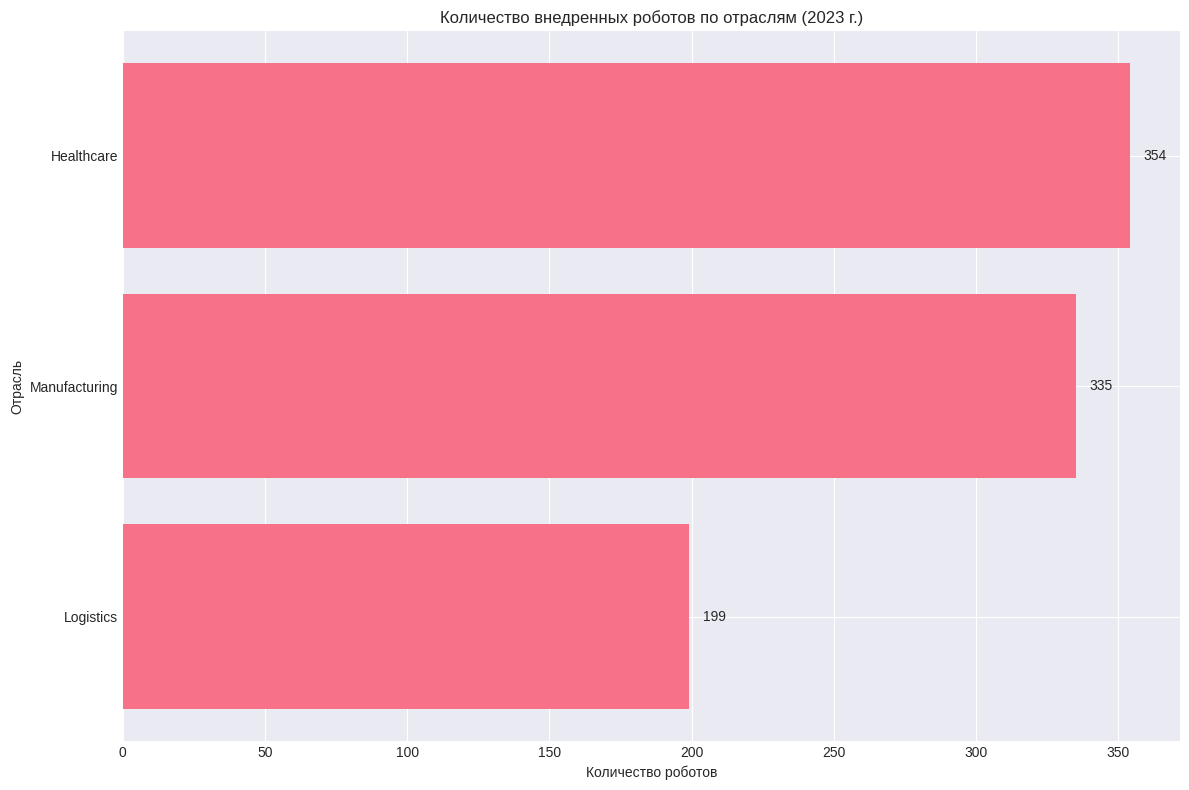

<Figure size 1200x800 with 0 Axes>

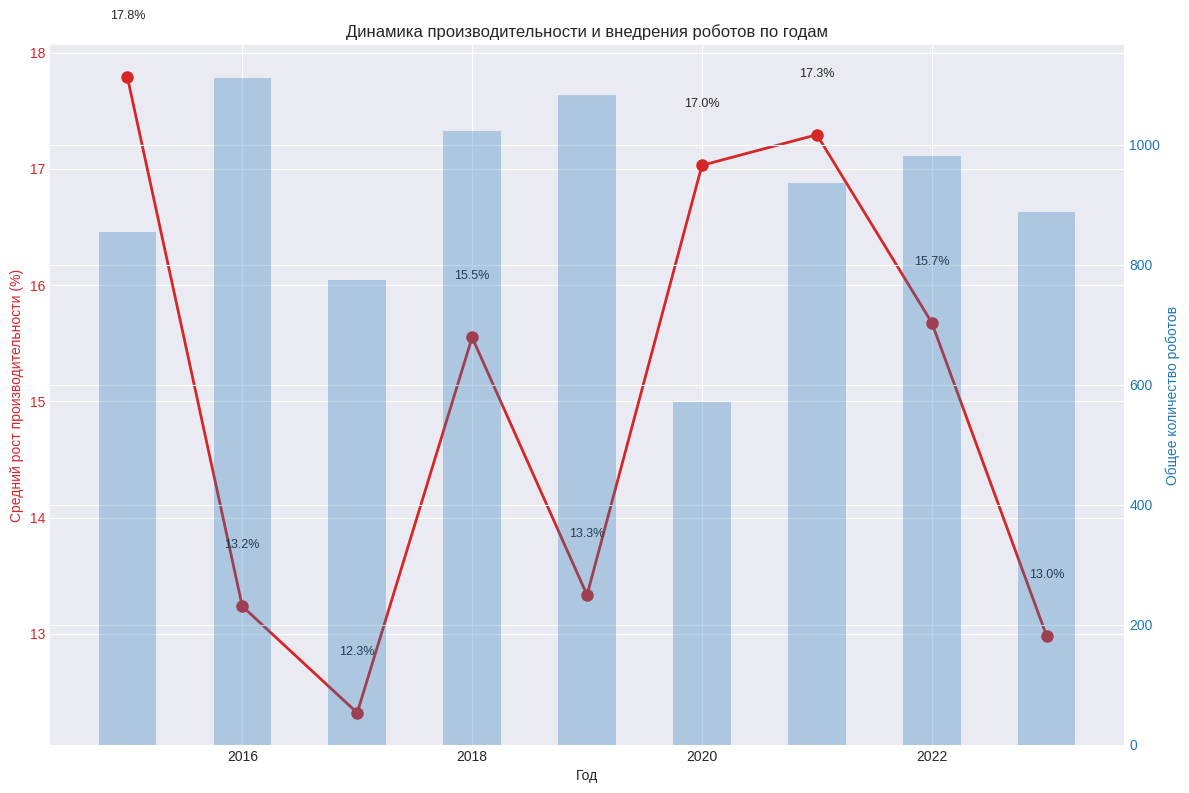

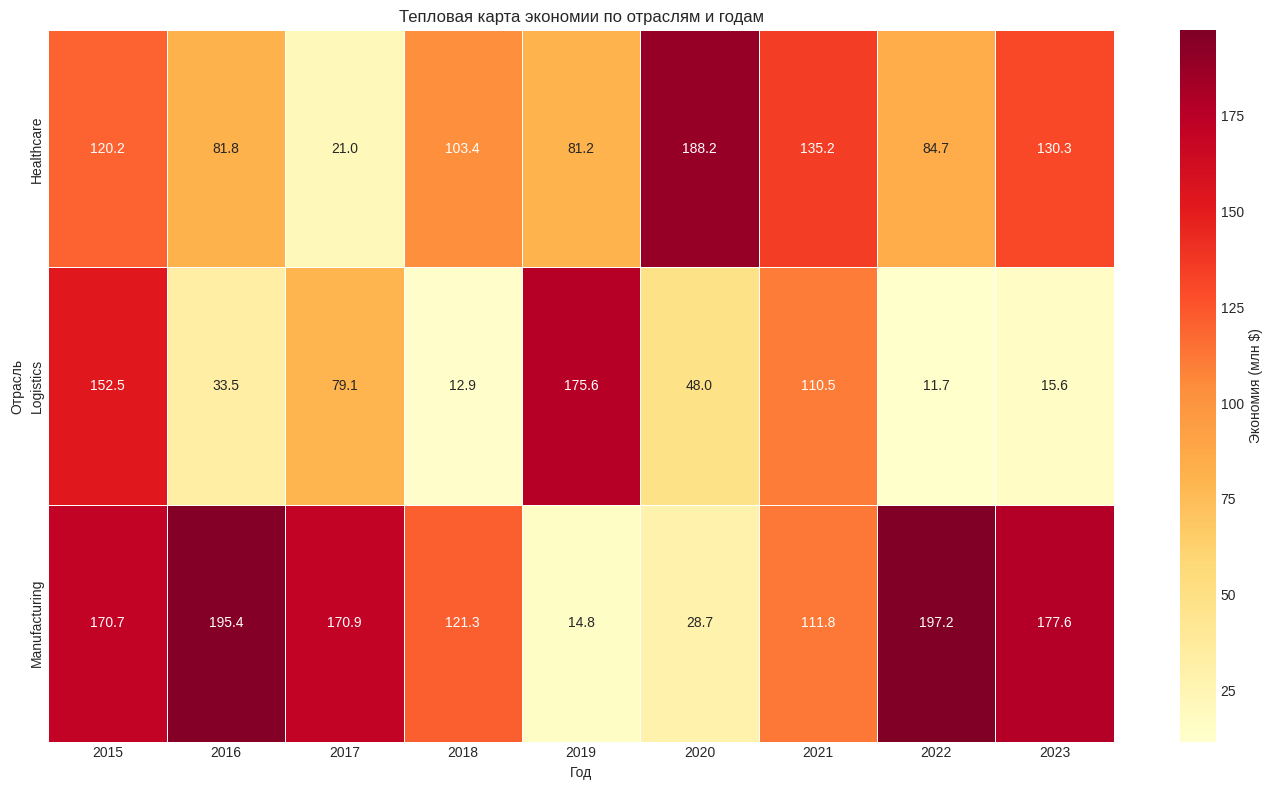

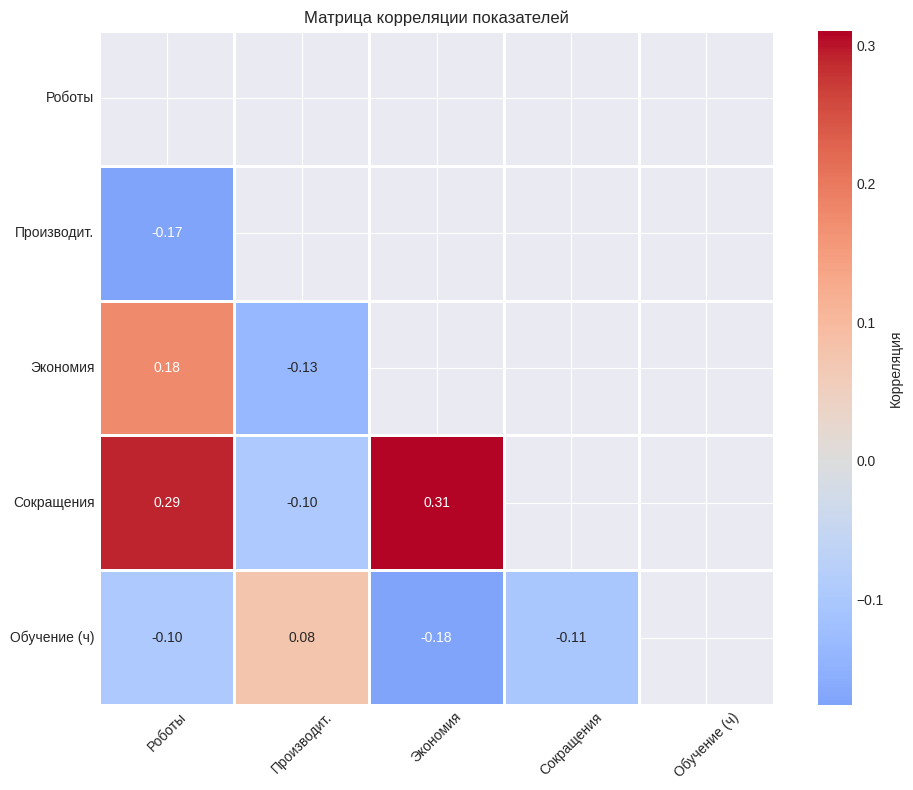

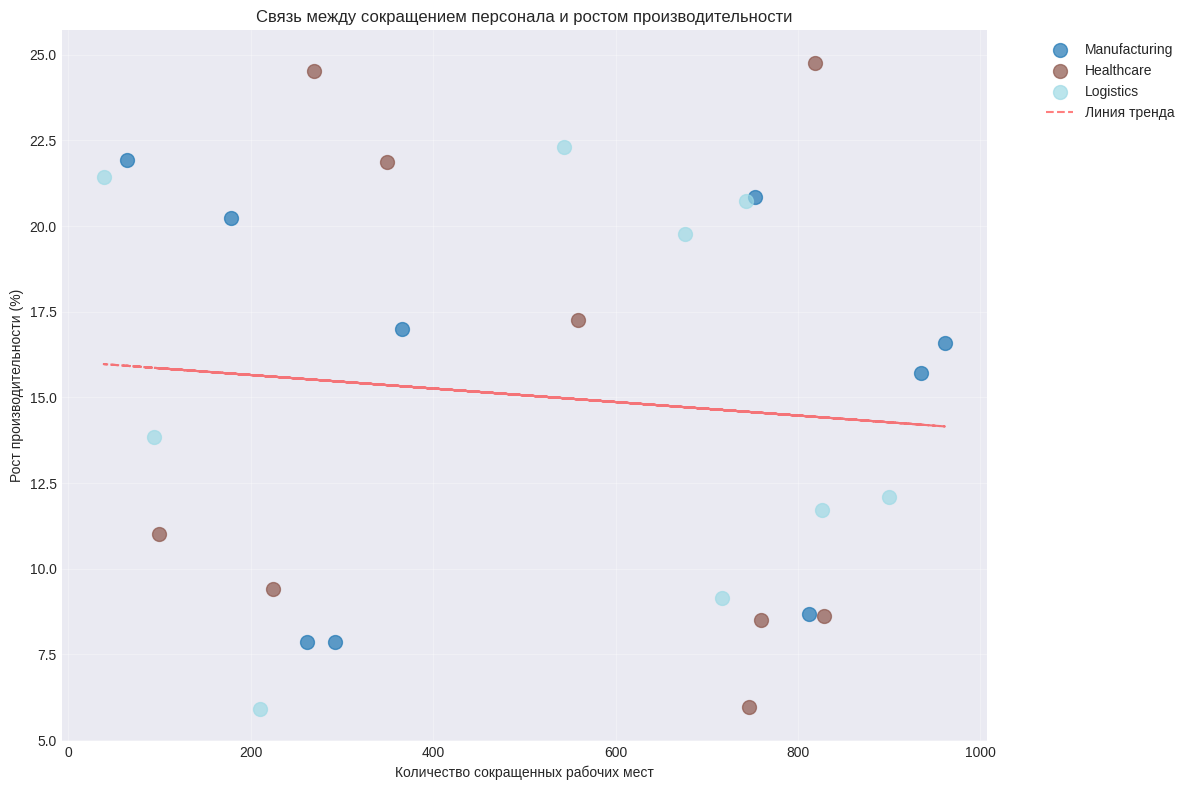

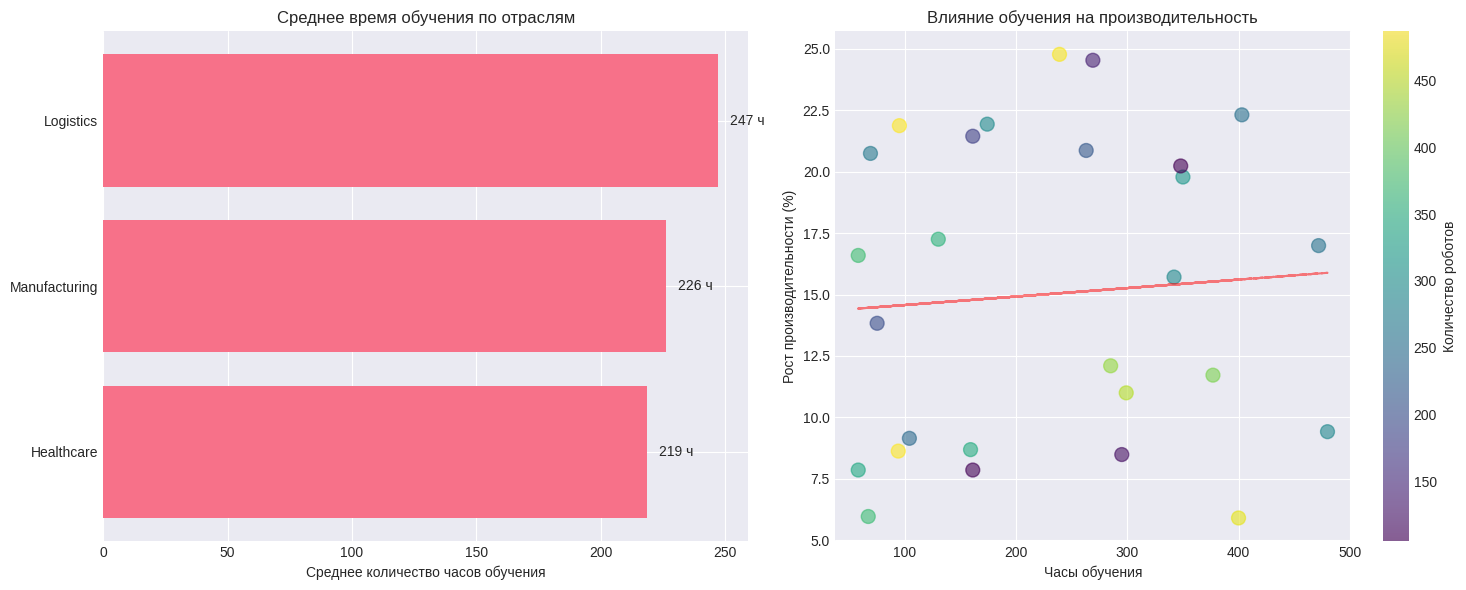

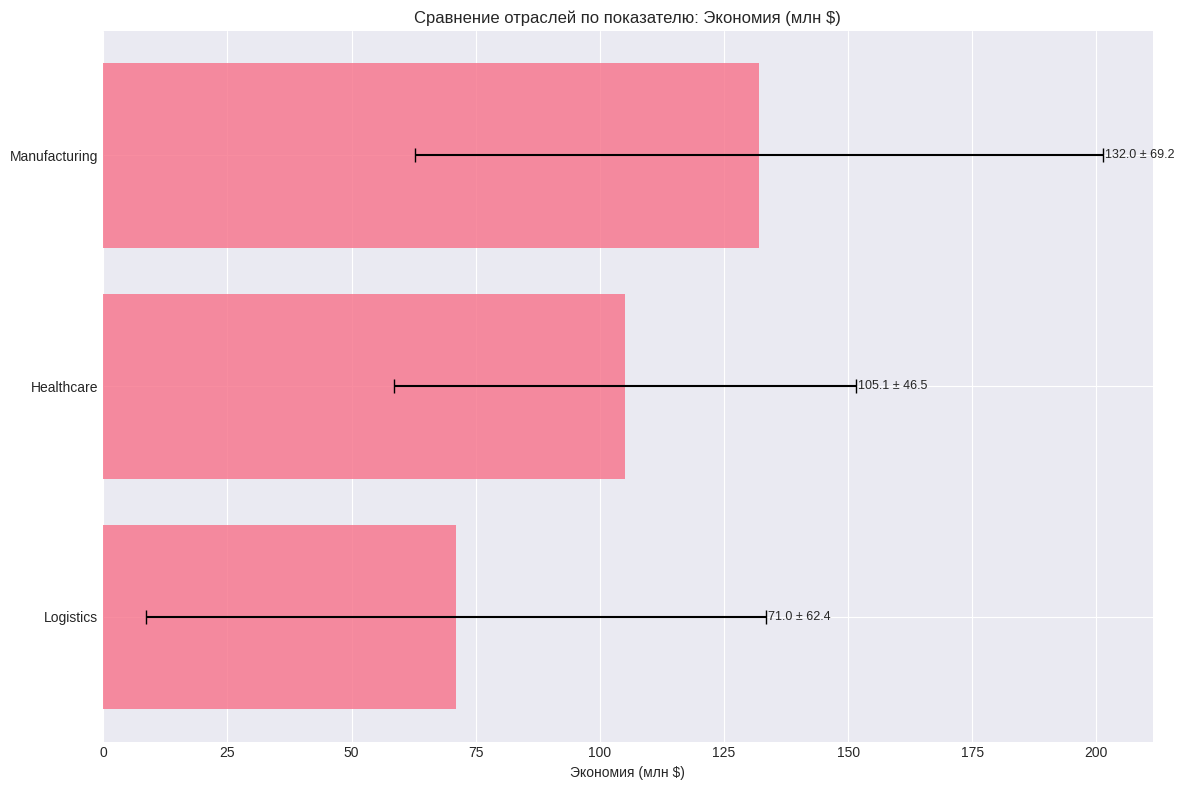

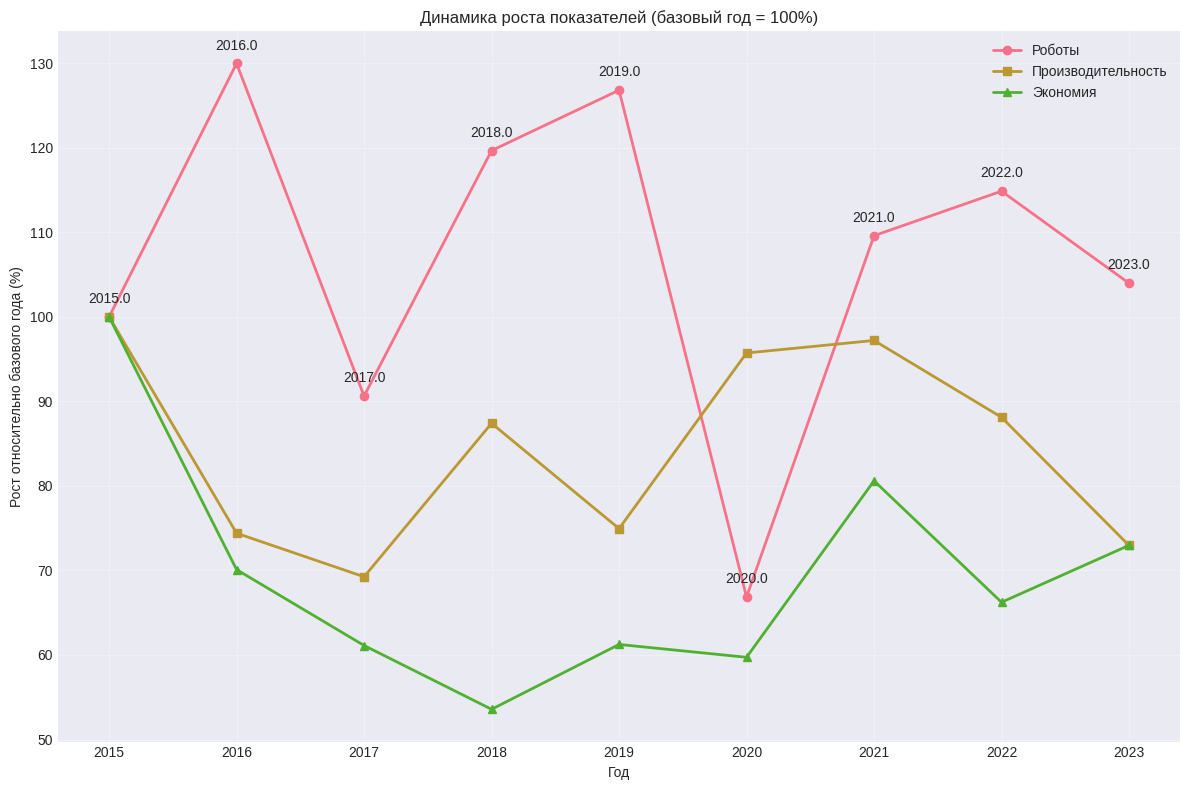

Содержимое лог-файла:
2026-02-22 13:26:55 - INFO - Data loaded to SQLite database
2026-02-22 13:26:55 - INFO - Создан график: Количество внедренных роботов по отраслям (2023 г.)
2026-02-22 13:26:55 - INFO - Создан график тренда производительности
2026-02-22 13:26:55 - INFO - Создана тепловая карта экономии
2026-02-22 13:26:56 - INFO - Создана матрица корреляции
2026-02-22 13:26:56 - INFO - Создана диаграмма рассеяния Jobs vs Productivity
2026-02-22 13:26:56 - INFO - Создан график влияния обучения
2026-02-22 13:26:56 - INFO - Создан график сравнения отраслей по Cost_Savings
2026-02-22 13:26:56 - INFO - Создан график годового роста
2026-02-22 13:38:32 - INFO - Data loaded to SQLite database
2026-02-22 13:38:32 - INFO - Создан график: Количество внедренных роботов по отраслям (2023 г.)
2026-02-22 13:38:32 - INFO - Создан график тренда производительности
2026-02-22 13:52:01 - INFO - Data loaded to SQLite database
2026-02-22 13:52:01 - INFO - Создан график: Количество внедренных роботов по 

In [1]:
#!pip install kaggle
import get_dataset as gd
import logger as lg
from data_sql import SQLData
import pandas as pd
from visual import Visual_Robot
import seaborn as sns
import matplotlib.pyplot as plt

# Определяем пути источника и назначения , добавить kaggle.json

gd.load_dataset_pdf()

!kaggle datasets download -d kennedywanakacha/industrial-robotics-and-automation-dataset
#распаковка .zip - файла
gd.unpacking_zip('industrial-robotics-and-automation-dataset.zip', 'industrial-robotics-and-automation-dataset')

gd.view_file('industrial-robotics-and-automation-dataset')

file_path='industrial-robotics-and-automation-dataset/robotics_data.csv'

gd.read_file(file_path)

file_path='industrial-robotics-and-automation-dataset/robotics_data.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
      lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

sq = SQLData(df)

# Подключение к SQLite базе данных и загрузка данных
print("\n1. Загрузка данных в БД...")
sq.sql_connect()
lg.log_event("INFO", "Data loaded to SQLite database")

# Проверка данных в БД
print("\n2. Проверка данных в БД:")
df_from_db = sq.sql_check()

# запрос данных из БД с отсечкой по годам
print("\n3. Данные после 2019 года:")
data_years_db = sq.sql_query("SELECT * FROM robotics_data WHERE Year > 2019")

# запрос роста производительности от кол-ва внедренных роботов
print("\n4. Связь между внедрением роботов и производительностью:")
adopted_db = sq.sql_query("SELECT Year, Industry, Robots_Adopted, Productivity_Gain FROM robotics_data ORDER BY Robots_Adopted DESC")

# запрос экономии по отраслям
print("\n5. Суммарная экономия по отраслям:")
cost_savings_db = sq.sql_query("SELECT Industry, SUM(Cost_Savings) as Total_Cost_Savings, AVG(Productivity_Gain) as Avg_Productivity FROM robotics_data GROUP BY Industry ORDER BY Total_Cost_Savings DESC")

vis = Visual_Robot(df)

vis.plot_robots_by_industry(2023)  # Только за 2023 год
vis.plot_productivity_trend()
vis.plot_cost_savings_heatmap()
vis.plot_correlation_matrix()
vis.plot_jobs_vs_productivity()
vis.plot_training_impact()
vis.plot_industry_comparison('Cost_Savings')  # Сравнение по экономии
vis.plot_yearly_growth()

if __name__ == "__main__":

    lg.read_log_file()

